# 🏪 Superstore Dataset - Analyse Bivariée des Performances Commerciales

**Objectif :** Identifier les facteurs clés influençant les ventes et la profitabilité pour optimiser la stratégie commerciale.

**Variables cibles :** `Sales`, `Profit`, `Region`, `Category`, `Sub-Category`, `Quantity`

---

## 0. Imports & Configuration

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE_REGION = {'West': '#2E86AB', 'East': '#A23B72', 'Central': '#F18F01', 'South': '#C73E1D'}
PALETTE_CAT    = {'Technology': '#2E86AB', 'Office Supplies': '#F18F01', 'Furniture': '#C73E1D'}

print('Librairies chargées avec succès.')

Librairies chargées avec succès.


## 1. Chargement & Aperçu des Données

In [10]:
df = pd.read_csv('Sample-Superstore.csv', encoding='latin-1')

# Conversions de dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Year']       = df['Order Date'].dt.year

print(f'Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

Shape : 9,994 lignes × 22 colonnes


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015


In [11]:
# Informations générales
print('=== Types & Valeurs manquantes ===')
info = pd.DataFrame({
    'dtype':   df.dtypes,
    'missing': df.isnull().sum(),
    'pct_missing': (df.isnull().mean()*100).round(2)
})
display(info[info['missing'] > 0] if info['missing'].sum() > 0 else 'Aucune valeur manquante')

print('\n=== Statistiques descriptives (variables clés) ===')
df[['Sales', 'Profit', 'Quantity', 'Discount']].describe().round(2)

=== Types & Valeurs manquantes ===


'Aucune valeur manquante'


=== Statistiques descriptives (variables clés) ===


,Sales,Profit,Quantity,Discount
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,3.79,0.16
std,623.25,234.26,2.23,0.21
min,0.44,-6599.98,1.00,0.00
25%,17.28,1.73,2.00,0.00
50%,54.49,8.67,3.00,0.20
75%,209.94,29.36,5.00,0.20
max,22638.48,8399.98,14.00,0.80


## 2. Feature Engineering

In [12]:
# Marge bénéficiaire (%)
df['Profit Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)

# Indicateur commande déficitaire
df['Is_Loss'] = df['Profit'] < 0

# Délai de livraison
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print('Nouvelles colonnes créées :', ['Profit Margin', 'Is_Loss', 'Delivery Days'])
df[['Sales', 'Profit', 'Profit Margin', 'Is_Loss', 'Delivery Days']].head()

Nouvelles colonnes créées : ['Profit Margin', 'Is_Loss', 'Delivery Days']


,Sales,Profit,Profit Margin,Is_Loss,Delivery Days
0,261.9600,41.9136,16.00,False,3
1,731.9400,219.5820,30.00,False,3
2,14.6200,6.8714,47.00,False,4
3,957.5775,-383.0310,-40.00,True,7
4,22.3680,2.5164,11.25,False,7


## 3. Statistiques Bivariées Quanti–Quanti

### 3.1 Matrice de Corrélations (Pearson & Spearman)

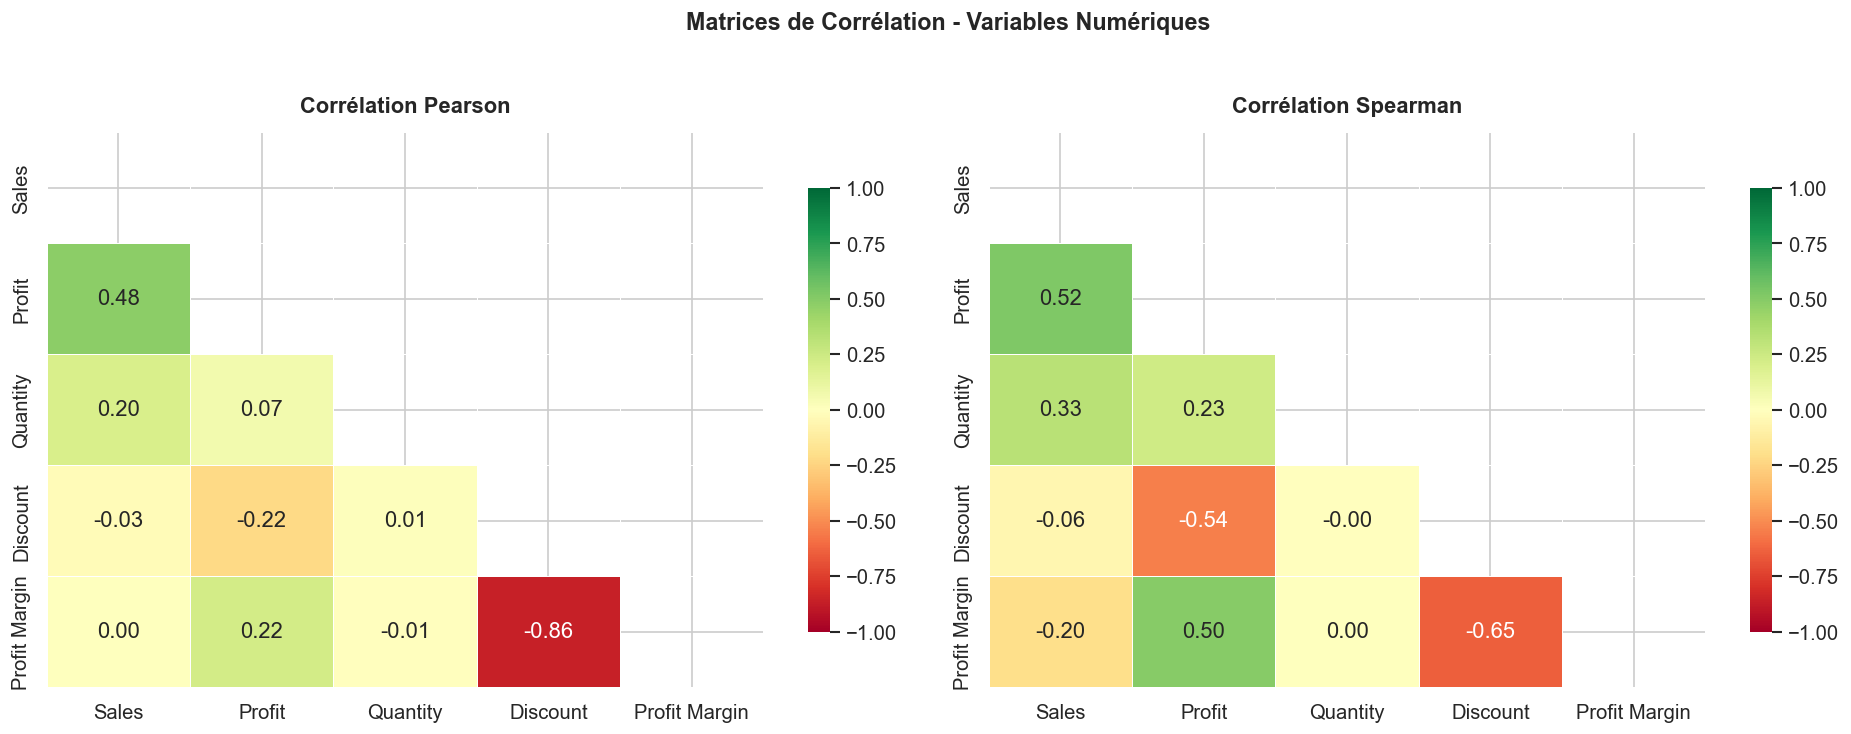


🔍 Corrélations clés (Pearson):


,Var1,Var2,Corrélation
0,Discount,Profit Margin,-0.864452
1,Sales,Profit,0.479064
2,Profit,Profit Margin,0.223732
3,Profit,Discount,-0.219487
4,Sales,Quantity,0.200795


In [14]:
num_vars = ['Sales', 'Profit', 'Quantity', 'Discount', 'Profit Margin']

corr_pearson  = df[num_vars].corr(method='pearson')
corr_spearman = df[num_vars].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, corr, title in zip(axes,
                            [corr_pearson, corr_spearman],
                            ['Pearson', 'Spearman']):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdYlGn', vmin=-1, vmax=1,
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'Corrélation {title}', fontweight='bold', pad=12)

plt.suptitle('Matrices de Corrélation - Variables Numériques', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n🔍 Corrélations clés (Pearson):')
corr_flat = corr_pearson.unstack().drop_duplicates().sort_values(key=abs, ascending=False)
corr_flat = corr_flat[corr_flat.index.get_level_values(0) != corr_flat.index.get_level_values(1)]
display(corr_flat[abs(corr_flat) > 0.1].reset_index().rename(
    columns={'level_0':'Var1','level_1':'Var2',0:'Corrélation'}
).drop_duplicates().head(10))

#### Interprétation : 
Plus on accorde de réduction (Discount), plus la marge bénéficiaire s'effondre (corrélation de -0.86) - c'est le facteur le plus destructeur de profit dans ce dataset ; à l'inverse, vendre plus (Sales) génère davantage de profit (corrélation de +0.48), mais augmenter la quantité vendue n'y contribue que faiblement (+0.20).

### 3.2 Scatter Plots : Sales vs Profit & Quantity vs Profit

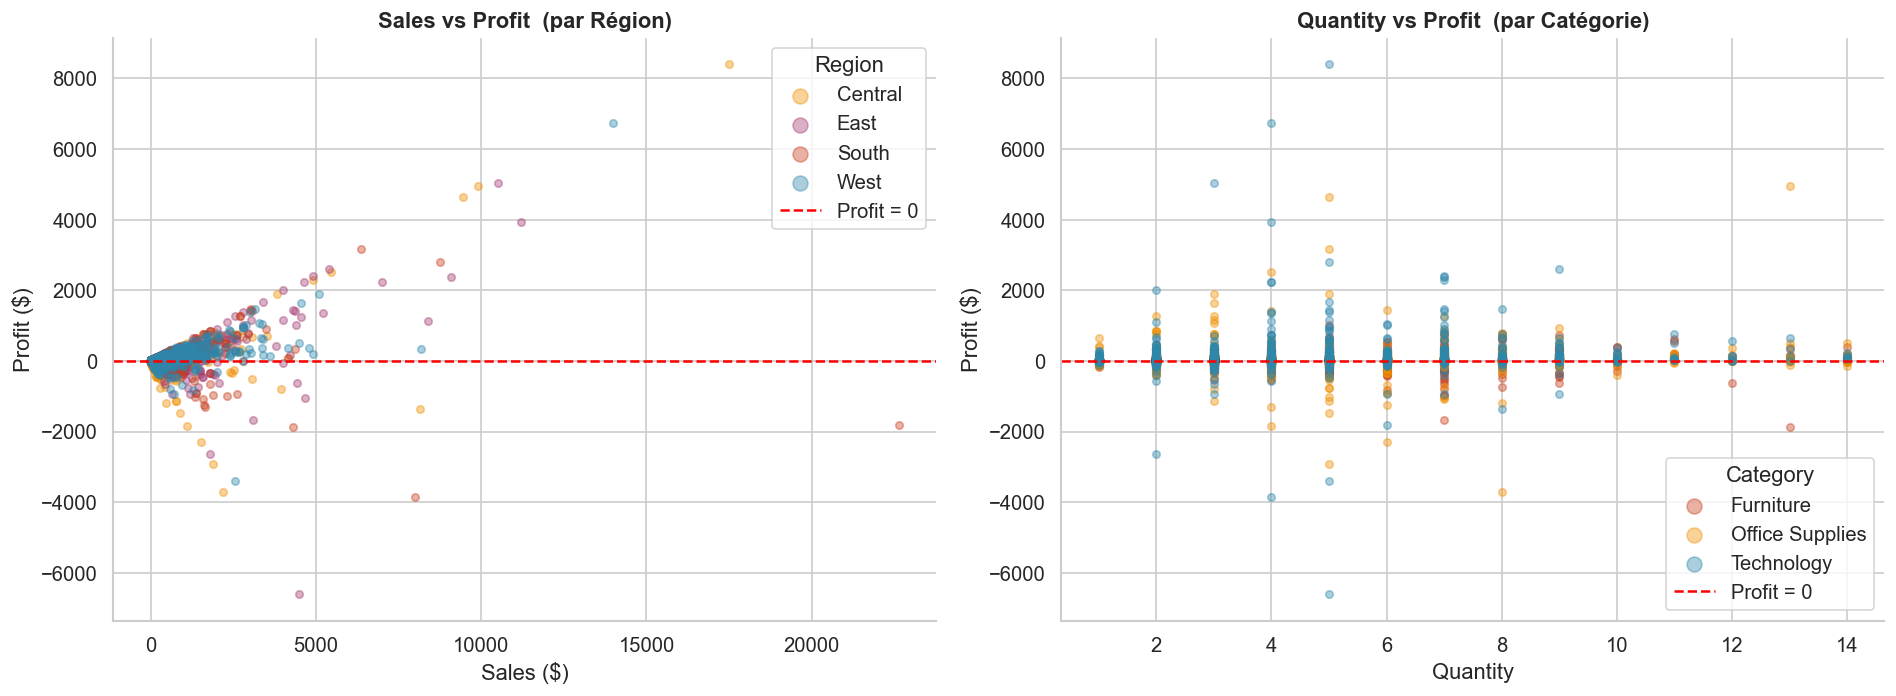

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales vs Profit (coloré par Region)
for region, grp in df.groupby('Region'):
    axes[0].scatter(grp['Sales'], grp['Profit'],
                    alpha=0.4, s=20, label=region,
                    color=PALETTE_REGION[region])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Profit = 0')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Profit ($)')
axes[0].set_title('Sales vs Profit  (par Région)', fontweight='bold')
axes[0].legend(title='Region', markerscale=2)

# Quantity vs Profit (coloré par Category)
for cat, grp in df.groupby('Category'):
    axes[1].scatter(grp['Quantity'], grp['Profit'],
                    alpha=0.4, s=20, label=cat,
                    color=PALETTE_CAT[cat])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Profit = 0')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Profit ($)')
axes[1].set_title('Quantity vs Profit  (par Catégorie)', fontweight='bold')
axes[1].legend(title='Category', markerscale=2)

plt.tight_layout()
plt.show()

#### Interprétation : 
Vendre plus en valeur (Sales élevés) tend à générer du profit, surtout dans les régions West et East - mais certaines ventes importantes restent déficitaires (sous la ligne rouge), ce qui trahit l'effet des remises excessives ; quant à la quantité d'articles achetés, elle n'a presque aucun impact sur le profit : qu'on achète 2 ou 14 unités, le résultat peut être positif ou négatif, toutes catégories confondues.

## 4. Analyses Bivariées Quanti–Quali

### 4.1 Profit & Marge par Région

In [16]:
region_stats = df.groupby('Region').agg(
    Sales_total   = ('Sales',         'sum'),
    Profit_total  = ('Profit',        'sum'),
    Profit_mean   = ('Profit',        'mean'),
    Profit_median = ('Profit',        'median'),
    Profit_std    = ('Profit',        'std'),
    Margin_mean   = ('Profit Margin', 'mean'),
    Orders        = ('Order ID',      'nunique')
).round(2).sort_values('Profit_total', ascending=False)

region_stats['Margin_global'] = (region_stats['Profit_total'] / region_stats['Sales_total'] * 100).round(2)

print('=== Statistiques par Région ===')
display(region_stats)

=== Statistiques par Région ===


,Sales_total,Profit_total,Profit_mean,Profit_median,Profit_std,Margin_mean,Orders,Margin_global
Region,,,,,,,,
West,725457.82,108418.45,33.85,11.17,174.11,21.95,1611,14.94
East,678781.24,91522.78,32.14,8.17,251.61,16.72,1401,13.48
South,391721.90,46749.43,28.86,9.07,212.89,16.35,822,11.93
Central,501239.89,39706.36,17.09,5.18,291.49,-10.41,1175,7.92


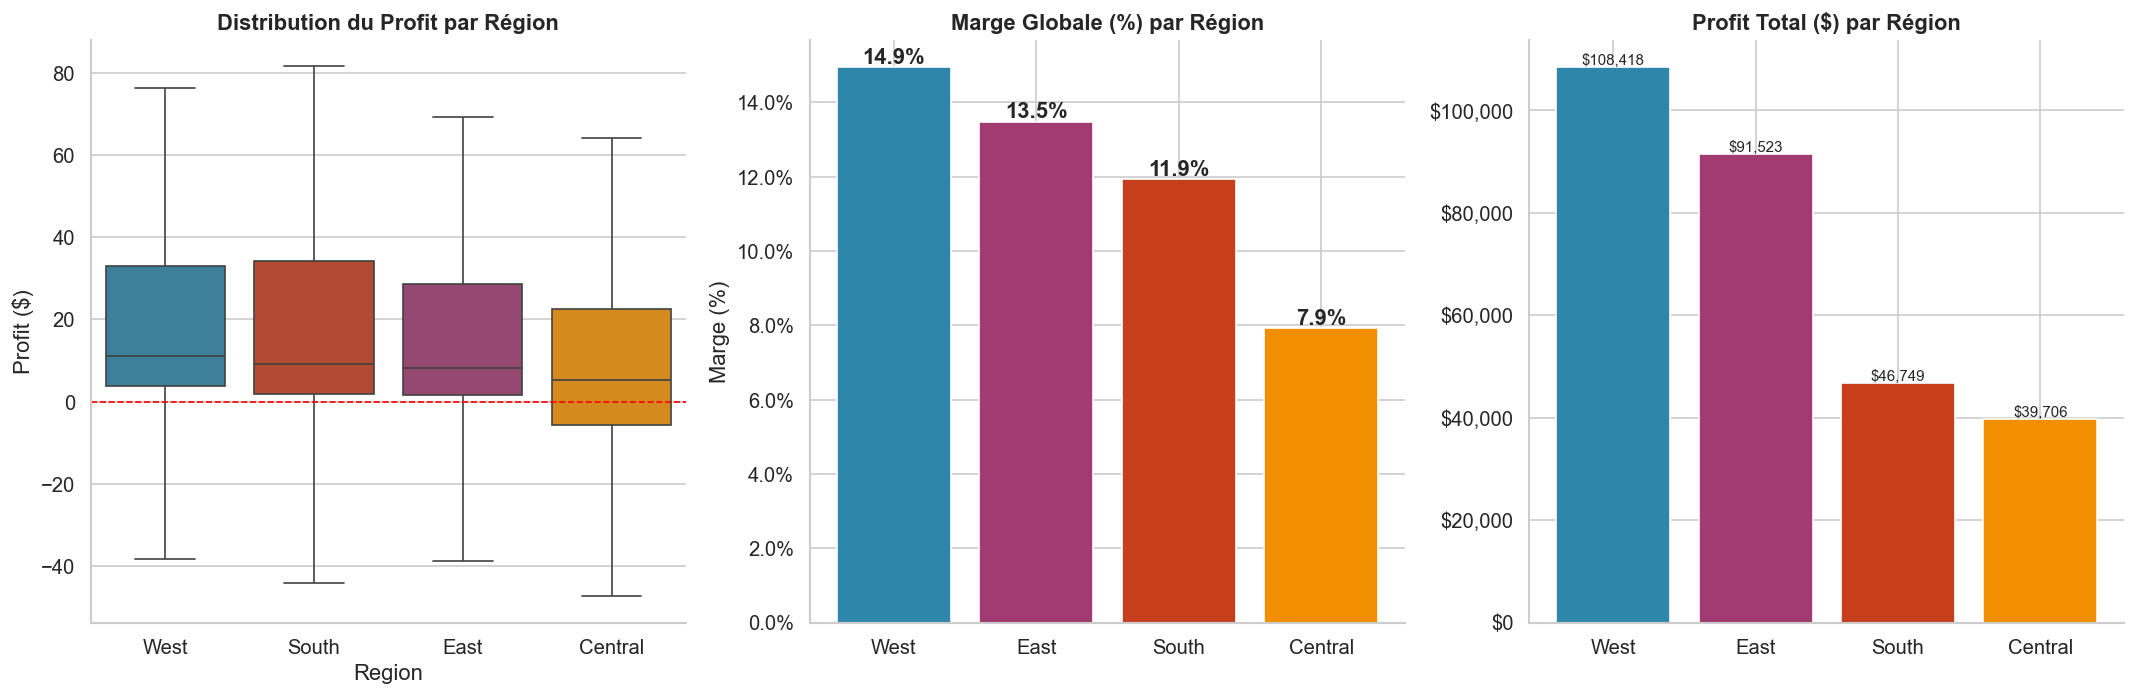

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot Profit par Region
order_reg = df.groupby('Region')['Profit'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Region', y='Profit', order=order_reg,
            palette=PALETTE_REGION, ax=axes[0], showfliers=False)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribution du Profit par Région', fontweight='bold')
axes[0].set_ylabel('Profit ($)')

# Marge globale par Region
colors = [PALETTE_REGION[r] for r in region_stats.index]
axes[1].bar(region_stats.index, region_stats['Margin_global'], color=colors, edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Marge Globale (%) par Région', fontweight='bold')
axes[1].set_ylabel('Marge (%)')
for i, (reg, val) in enumerate(region_stats['Margin_global'].items()):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontweight='bold')

# Profit total par Region
axes[2].bar(region_stats.index, region_stats['Profit_total'], color=colors, edgecolor='white')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].set_title('Profit Total ($) par Région', fontweight='bold')
for i, (reg, val) in enumerate(region_stats['Profit_total'].items()):
    axes[2].text(i, val + 500, f'${val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#### Interprétation : 
West est clairement la région la plus rentable (marge de 14,9% et $108 418 de profit total), tandis que Central est la plus problématique avec seulement 7,9% de marge et un boxplot dont la médiane frôle zéro — ce qui signifie que la moitié des commandes en Central génèrent à peine du profit, voire des pertes.

### 4.2 Test ANOVA — Profit entre Régions

In [18]:
groups = [grp['Profit'].values for _, grp in df.groupby('Region')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'ANOVA — Profit par Région')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_val:.4e}')
print(f'  Conclusion  : {"✅ Différences significatives (p < 0.05)" if p_val < 0.05 else "❌ Pas de différence significative"}')

# T-test : West vs East
west  = df[df['Region'] == 'West']['Profit']
east  = df[df['Region'] == 'East']['Profit']
t, p  = stats.ttest_ind(west, east)
print(f'\nT-test West vs East')
print(f'  t-statistic : {t:.4f}')
print(f'  p-value     : {p:.4f}')
print(f'  Conclusion  : {"✅ Différence significative" if p < 0.05 else "❌ Pas de différence significative"}')

ANOVA — Profit par Région
  F-statistic : 2.6225
  p-value     : 4.8892e-02
  Conclusion  : ✅ Différences significatives (p < 0.05)

T-test West vs East
  t-statistic : 0.3107
  p-value     : 0.7561
  Conclusion  : ❌ Pas de différence significative


#### Interprétation : 
Les 4 régions ont des profits statistiquement différents dans l'ensemble (ANOVA confirmée), mais West et East se ressemblent tellement qu'on ne peut pas dire que l'une performe vraiment mieux que l'autre. La vraie fracture se situe donc entre le duo West/East (performants) et le duo South/Central (à la traîne).

### 4.3 Profit & Marge par Catégorie

,Sales_total,Profit_total,Margin_mean,Orders,Margin_global
Category,,,,,
Technology,836154.03,145454.95,15.61,1544,17.40
Office Supplies,719047.03,122490.80,13.80,3742,17.04
Furniture,741999.80,18451.27,3.88,1764,2.49


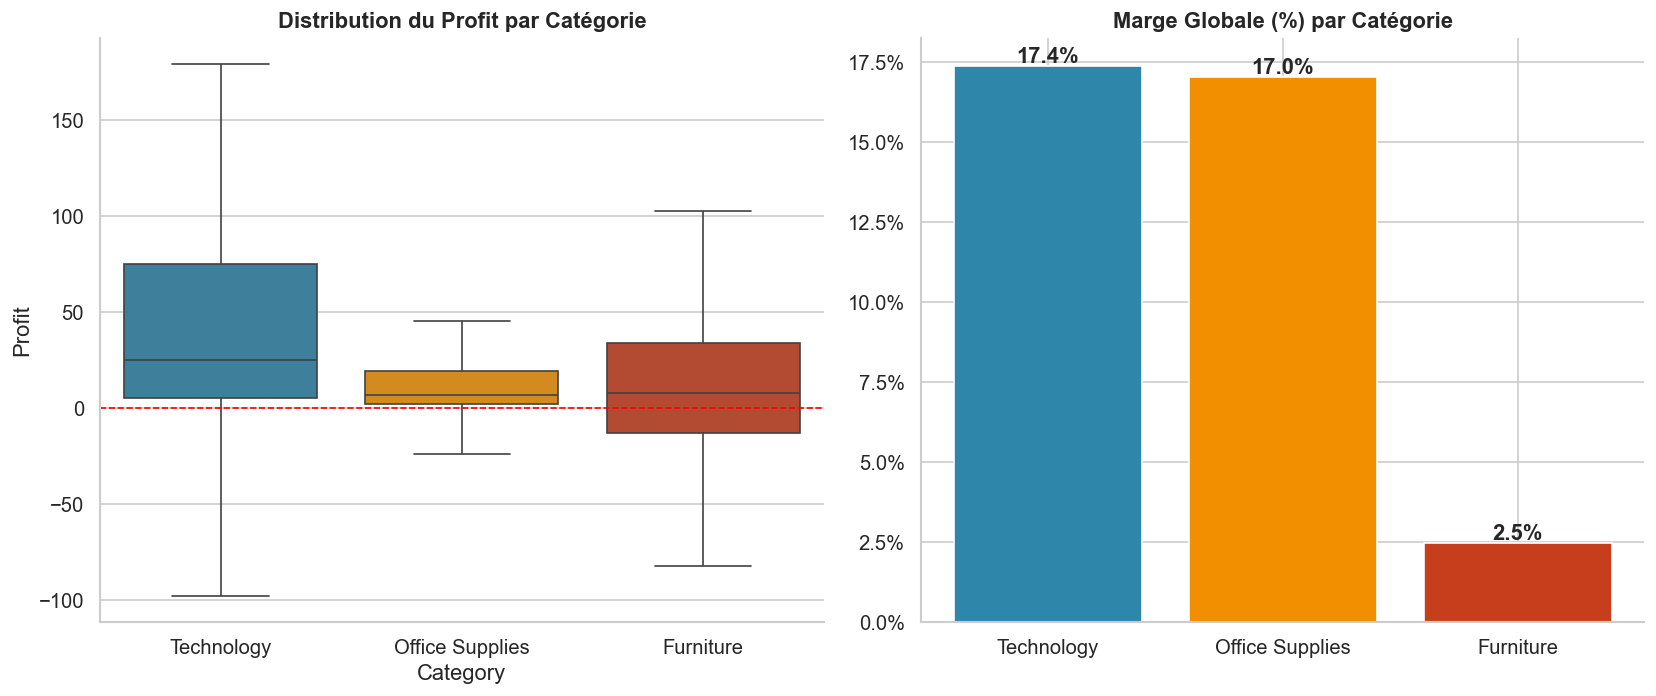

In [19]:
cat_stats = df.groupby('Category').agg(
    Sales_total  = ('Sales',         'sum'),
    Profit_total = ('Profit',        'sum'),
    Margin_mean  = ('Profit Margin', 'mean'),
    Orders       = ('Order ID',      'nunique')
).round(2)
cat_stats['Margin_global'] = (cat_stats['Profit_total'] / cat_stats['Sales_total'] * 100).round(2)
display(cat_stats.sort_values('Profit_total', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot Profit par Category
order_cat = cat_stats.sort_values('Profit_total', ascending=False).index
sns.boxplot(data=df, x='Category', y='Profit', order=order_cat,
            palette=PALETTE_CAT, ax=axes[0], showfliers=False)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribution du Profit par Catégorie', fontweight='bold')

# Marge globale
colors_cat = [PALETTE_CAT[c] for c in order_cat]
axes[1].bar(order_cat, cat_stats.loc[order_cat, 'Margin_global'], color=colors_cat, edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Marge Globale (%) par Catégorie', fontweight='bold')
for i, cat in enumerate(order_cat):
    val = cat_stats.loc[cat, 'Margin_global']
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Interprétation : 
Technology et Office Supplies sont presque à égalité avec une marge saine autour de 17%, tandis que Furniture est le grand perdant : malgré $742 000 de ventes, sa marge ne dépasse pas 2,5% et son boxplot passe carrément sous zéro, ce qui signifie qu'une bonne partie des commandes de meubles font perdre de l'argent à l'entreprise.

### 4.4 Impact du Discount sur le Profit

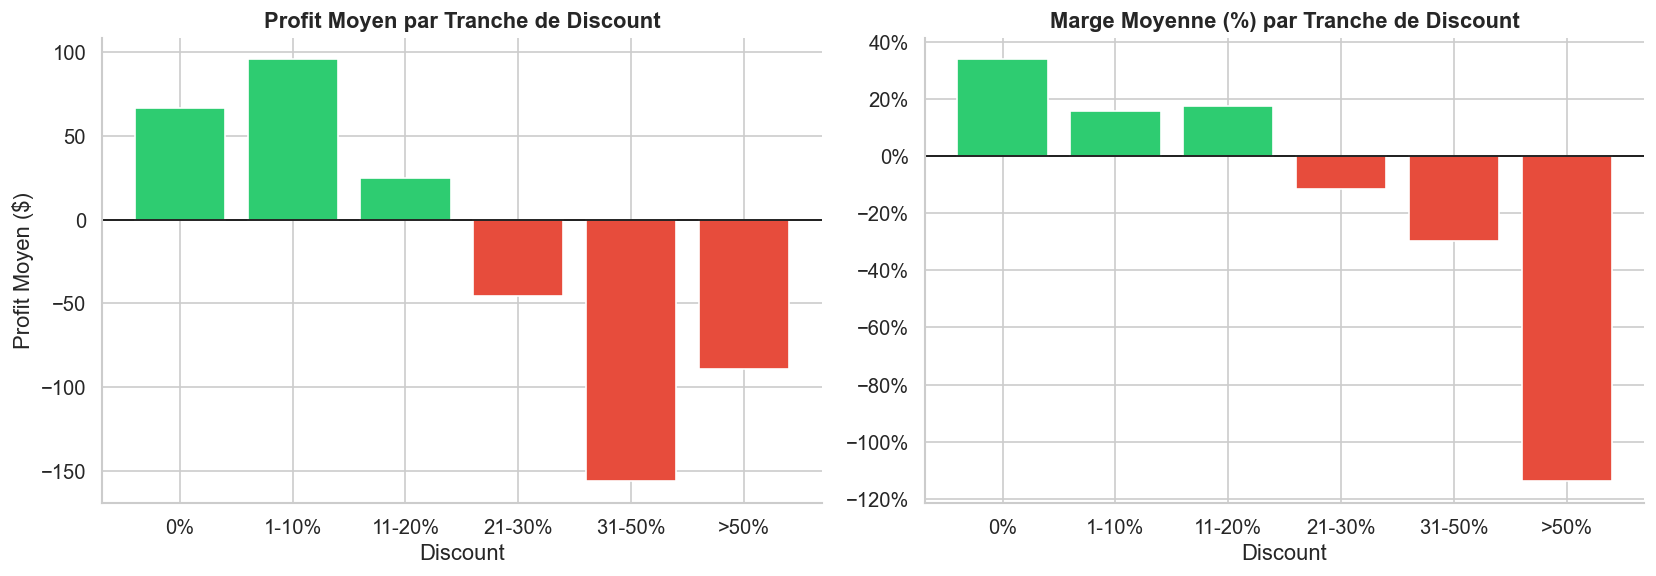

Discount_bin  Profit_mean  Margin_mean  Count
          0%    66.900292    34.016048   4798
       1-10%    96.055074    15.579468     94
      11-20%    24.738824    17.483874   3709
      21-30%   -45.679636   -11.548414    227
      31-50%  -156.282991   -29.606355    310
        >50%   -89.438144  -113.878493    856


In [20]:
# Discrétisation du Discount
df['Discount_bin'] = pd.cut(df['Discount'],
                            bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
                            labels=['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%'])

disc_stats = df.groupby('Discount_bin')[['Profit','Profit Margin','Sales']].agg(
    Profit_mean   = ('Profit', 'mean'),
    Margin_mean   = ('Profit Margin', 'mean'),
    Count         = ('Sales', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in disc_stats['Profit_mean']]
axes[0].bar(disc_stats['Discount_bin'].astype(str), disc_stats['Profit_mean'], color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Profit Moyen par Tranche de Discount', fontweight='bold')
axes[0].set_xlabel('Discount')
axes[0].set_ylabel('Profit Moyen ($)')

colors2 = ['#2ecc71' if v >= 0 else '#e74c3c' for v in disc_stats['Margin_mean']]
axes[1].bar(disc_stats['Discount_bin'].astype(str), disc_stats['Margin_mean'], color=colors2, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Marge Moyenne (%) par Tranche de Discount', fontweight='bold')
axes[1].set_xlabel('Discount')

plt.tight_layout()
plt.show()

print(disc_stats.to_string(index=False))

#### Interprétation : 
Le seuil de 20% de réduction est un point de rupture critique : en dessous, l'entreprise gagne de l'argent (jusqu'à +34% de marge sans remise) ; au-dessus, chaque commande devient une perte sèche, et les remises supérieures à 50%, accordées sur 856 commandes, détruisent complètement la marge avec -114% en moyenne, ce qui signifie que l'entreprise vend littéralement à perte en payant plus que ce qu'elle encaisse.

## 5. Tableaux Croisés Quali–Quali

### 5.1 Ventes & Profit - Category × Region

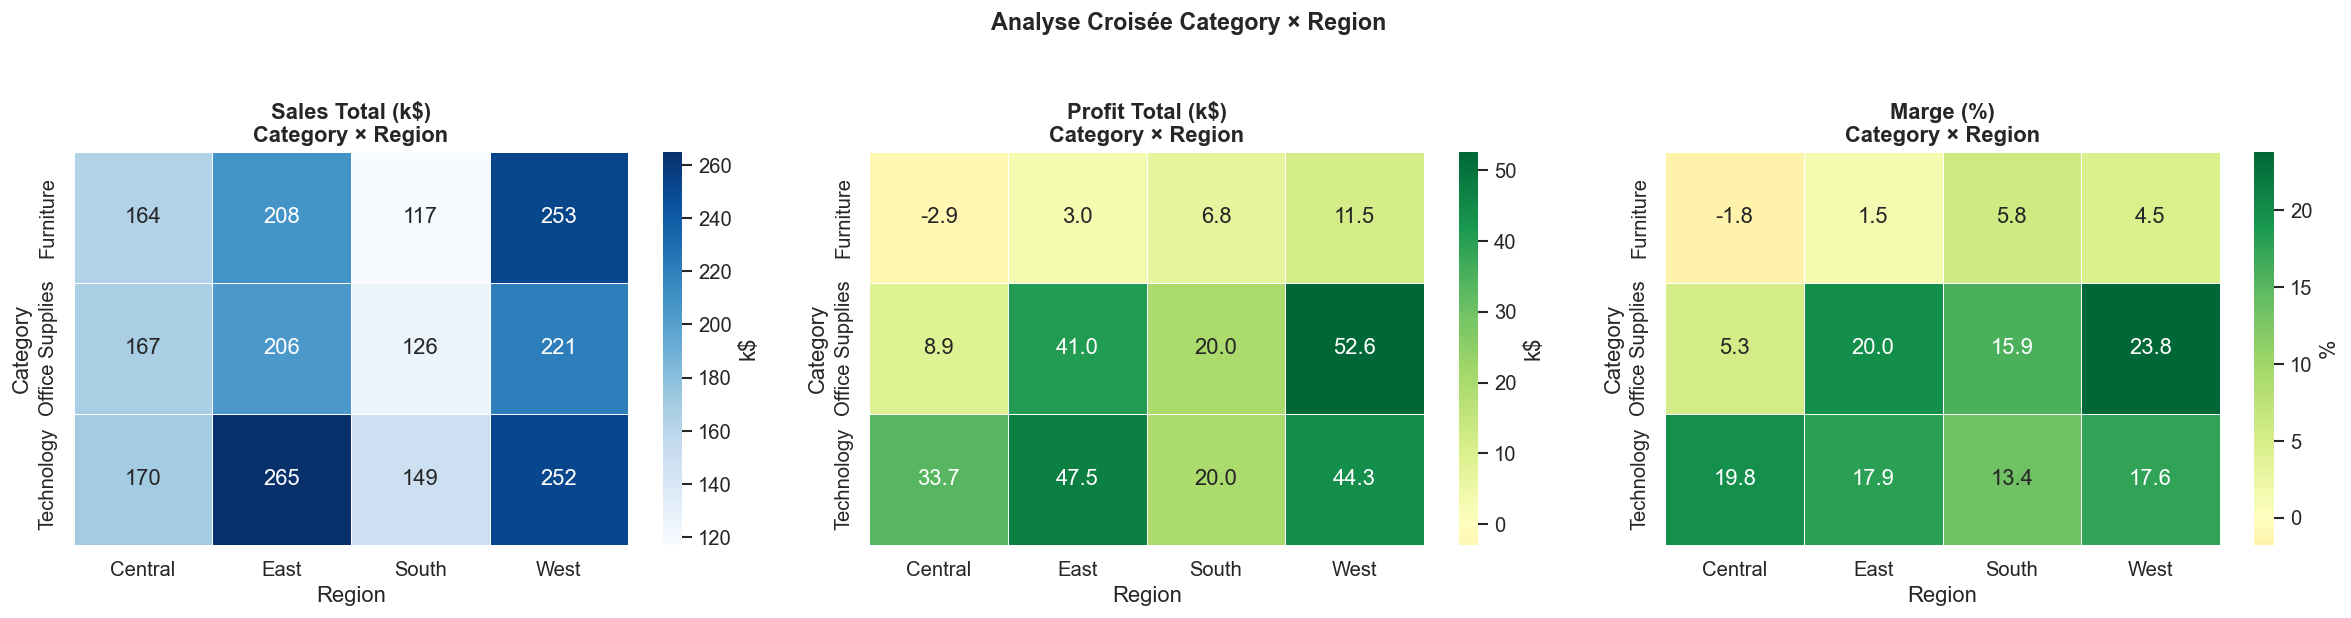

In [21]:
# Table croisée — Sales
ct_sales = pd.crosstab(df['Category'], df['Region'],
                       values=df['Sales'], aggfunc='sum').round(0)
ct_profit = pd.crosstab(df['Category'], df['Region'],
                        values=df['Profit'], aggfunc='sum').round(0)
ct_margin = (ct_profit / ct_sales * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(ct_sales/1000, annot=True, fmt='.0f', cmap='Blues',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'k$'})
axes[0].set_title('Sales Total (k$)\nCategory × Region', fontweight='bold')

sns.heatmap(ct_profit/1000, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, center=0, cbar_kws={'label': 'k$'})
axes[1].set_title('Profit Total (k$)\nCategory × Region', fontweight='bold')

sns.heatmap(ct_margin, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[2], linewidths=0.5, center=0, cbar_kws={'label': '%'})
axes[2].set_title('Marge (%)\nCategory × Region', fontweight='bold')

plt.suptitle('Analyse Croisée Category × Region', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

#### Interprétation : 
Furniture est la seule catégorie qui perd de l'argent en Central (-1.8% de marge, soit -2.9k$ de profit) malgré 164k de ventes, confirmant que c'est la combinaison Furniture × Central le point le plus critique à corriger, pendant ce temps, Office Supplies × West est la combinaison la plus rentable en marge (23.8%), ce qui en fait la priorité d'investissement numéro un.

### 5.2 Top & Flop Sub-Categories

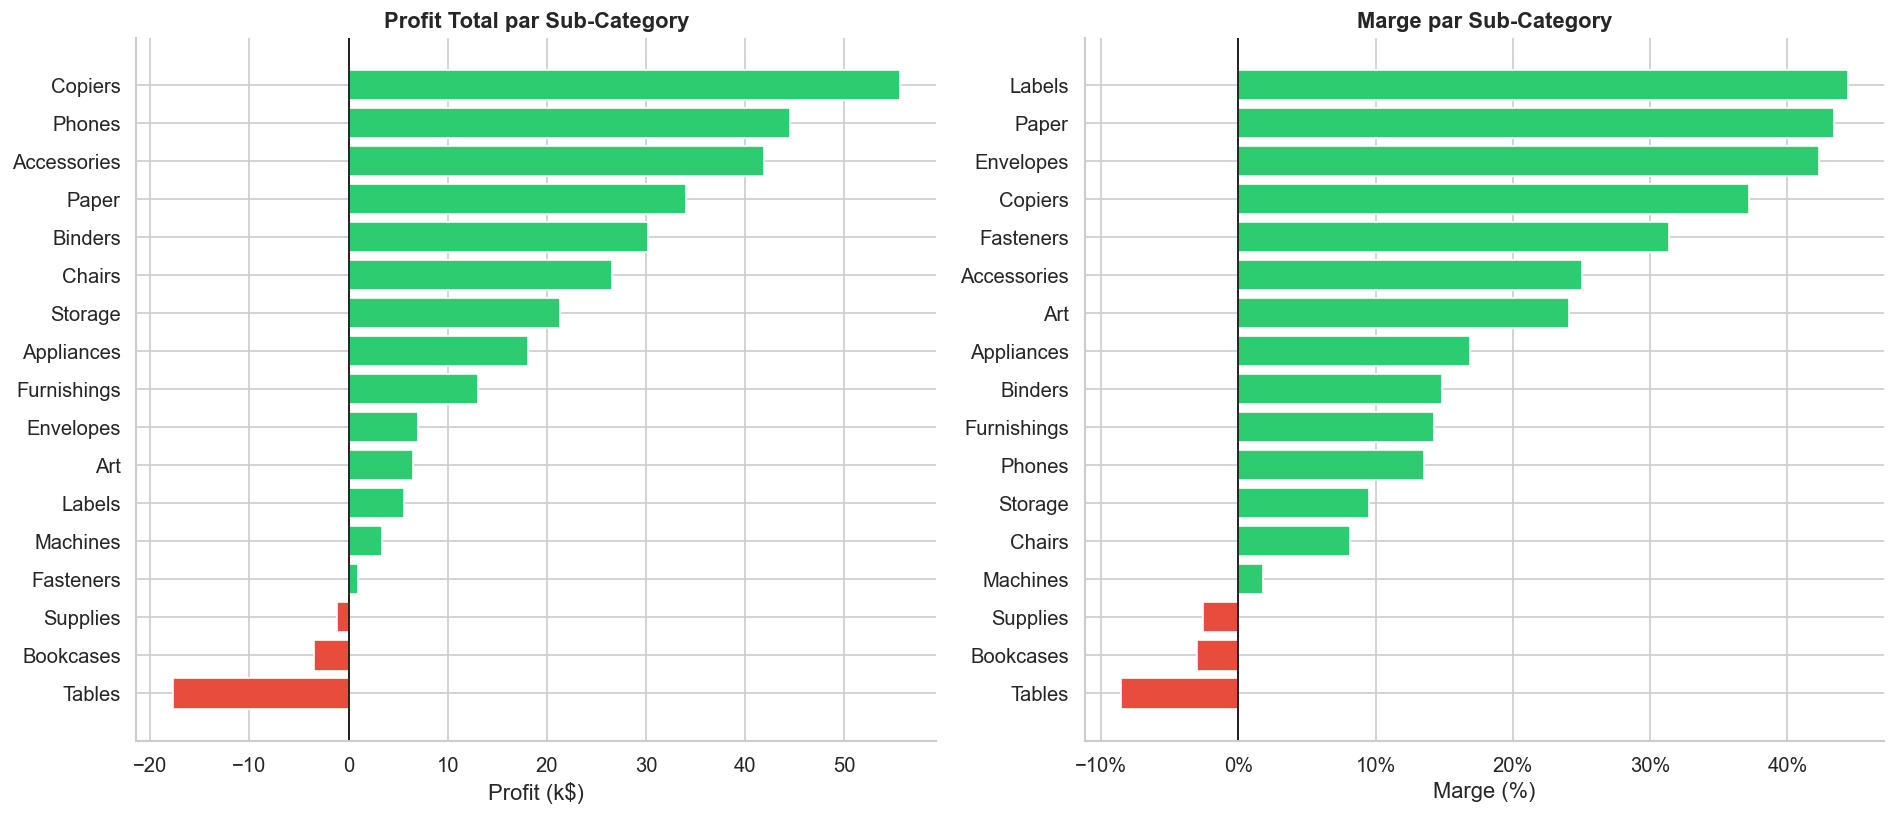

🔴 Flop Sub-Categories (Profit négatif):


,Category,Sub-Category,Sales,Profit,Margin
3,Furniture,Tables,206965.5320,-17725.4811,-8.56
0,Furniture,Bookcases,114879.9963,-3472.5560,-3.02
12,Office Supplies,Supplies,46673.5380,-1189.0995,-2.55


In [22]:
subcat = df.groupby(['Category', 'Sub-Category']).agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).reset_index()
subcat['Margin'] = (subcat['Profit'] / subcat['Sales'] * 100).round(2)
subcat = subcat.sort_values('Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Profit par Sub-Category
colors_bar = ['#2ecc71' if v >= 0 else '#e74c3c' for v in subcat['Profit']]
axes[0].barh(subcat['Sub-Category'], subcat['Profit'] / 1000, color=colors_bar, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Profit (k$)')
axes[0].set_title('Profit Total par Sub-Category', fontweight='bold')
axes[0].invert_yaxis()

# Marge par Sub-Category
colors_bar2 = ['#2ecc71' if v >= 0 else '#e74c3c' for v in subcat.sort_values('Margin')['Margin']]
sub_sorted = subcat.sort_values('Margin')
axes[1].barh(sub_sorted['Sub-Category'], sub_sorted['Margin'], color=colors_bar2, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlabel('Marge (%)')
axes[1].set_title('Marge par Sub-Category', fontweight='bold')

plt.tight_layout()
plt.show()

print('🔴 Flop Sub-Categories (Profit négatif):')
display(subcat[subcat['Profit'] < 0][['Category','Sub-Category','Sales','Profit','Margin']].sort_values('Profit'))

#### Interprétation : 
Trois sous-catégories font perdre de l'argent à l'entreprise, Tables est la pire avec -17 725$ de perte malgré 207 000USD de ventes (marge de -8.56%), suivie de Bookcases et Supplies, pendant ce temps, Copiers et Labels dominent avec les meilleures marges (35-44%), ce qui signifie que l'entreprise devrait revoir sa stratégie de prix sur Tables et Bookcases en priorité, car elle vend beaucoup mais perd à chaque transaction.

### 5.3 Barplot Empilé — Ventes par Category et Region

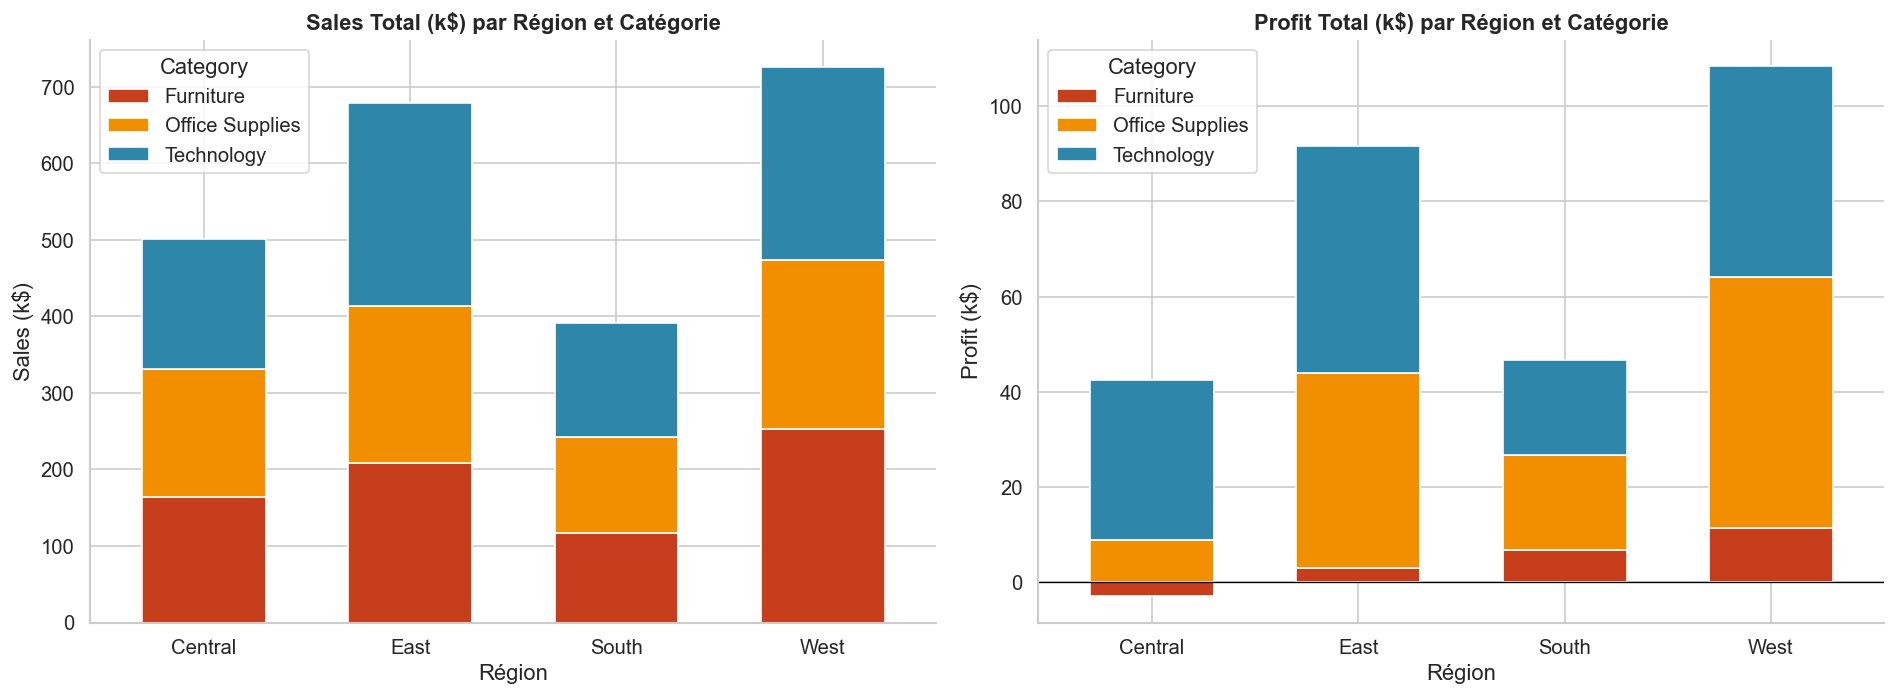

In [23]:
pivot_sales  = df.pivot_table(values='Sales',  index='Region', columns='Category', aggfunc='sum') / 1000
pivot_profit = df.pivot_table(values='Profit', index='Region', columns='Category', aggfunc='sum') / 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_sales.plot(kind='bar', stacked=True, ax=axes[0],
                 color=[PALETTE_CAT[c] for c in pivot_sales.columns],
                 edgecolor='white', width=0.6)
axes[0].set_title('Sales Total (k$) par Région et Catégorie', fontweight='bold')
axes[0].set_xlabel('Région')
axes[0].set_ylabel('Sales (k$)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Category')

pivot_profit.plot(kind='bar', stacked=True, ax=axes[1],
                  color=[PALETTE_CAT[c] for c in pivot_profit.columns],
                  edgecolor='white', width=0.6)
axes[1].set_title('Profit Total (k$) par Région et Catégorie', fontweight='bold')
axes[1].set_xlabel('Région')
axes[1].set_ylabel('Profit (k$)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Category')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

#### Interprétation : 
Furniture (en rouge) génère des ventes significatives dans toutes les régions mais n'apporte quasiment aucun profit, voire plombe Central dans le négatif, tandis que Technology (bleu) et Office Supplies (orange) portent l'essentiel des bénéfices partout, et c'est West qui cumule le meilleur des deux mondes : volume de ventes élevé ET profit solide sur les trois catégories.

## 6. Analyse par Ship Mode & Segment

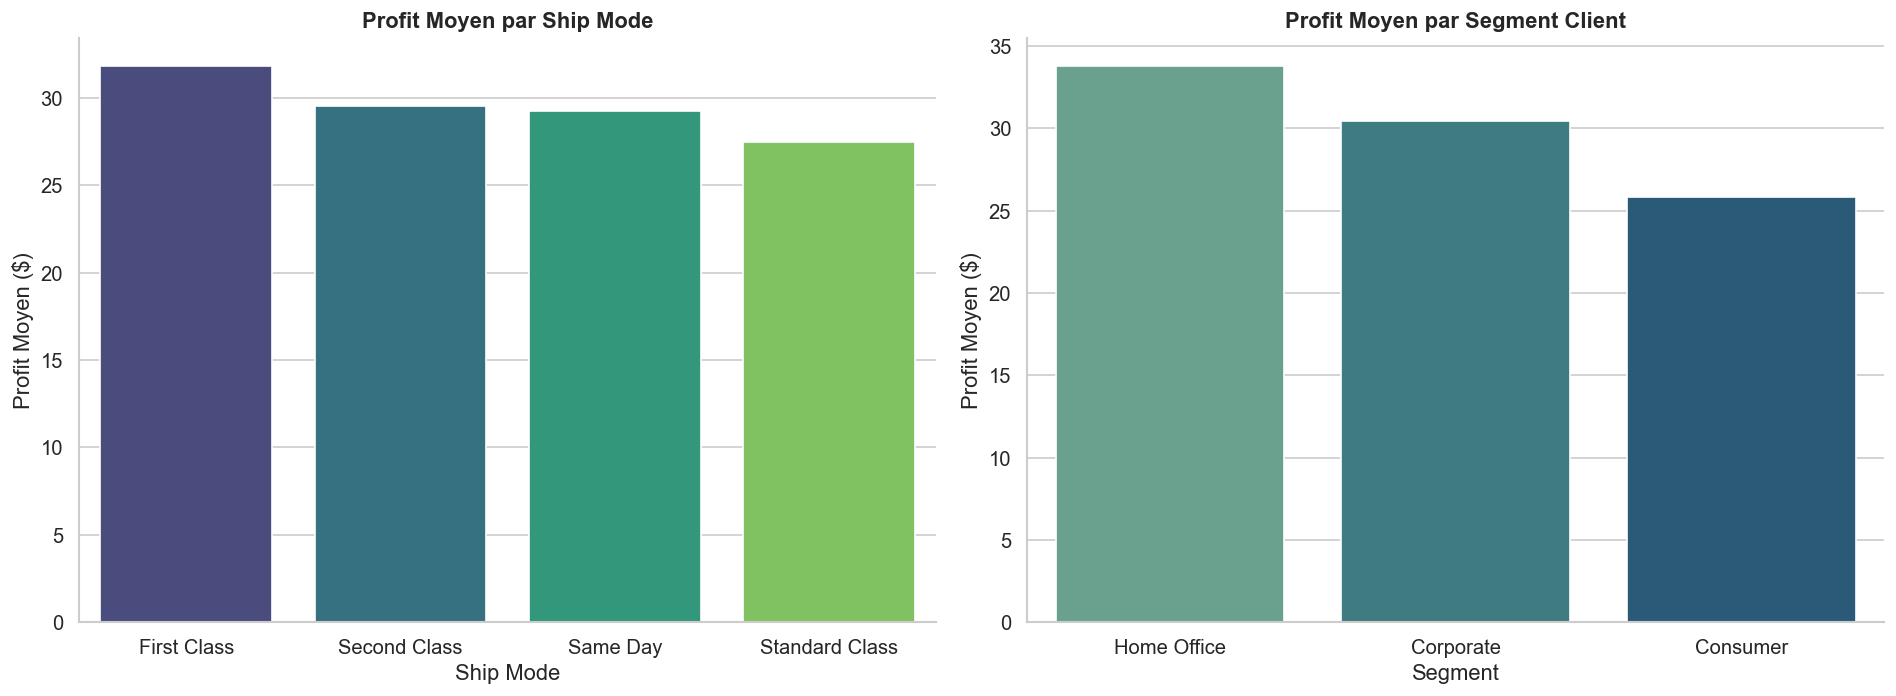

=== Ship Mode Stats ===


,Ship Mode,Profit_mean,Margin_mean,Count
0,First Class,31.839948,11.594766,1538
2,Second Class,29.535545,15.020879,1945
1,Same Day,29.266591,13.815120,543
3,Standard Class,27.494770,11.007329,5968



=== Segment Stats ===


,Segment,Profit_mean,Margin_mean,Sales_total
2,Home Office,33.818664,14.286971,4.296531e+05
1,Corporate,30.456667,12.120238,7.061464e+05
0,Consumer,25.836873,11.204955,1.161401e+06


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Profit par Ship Mode
ship_stats = df.groupby('Ship Mode').agg(
    Profit_mean   = ('Profit', 'mean'),
    Margin_mean   = ('Profit Margin', 'mean'),
    Count         = ('Sales', 'count')
).reset_index().sort_values('Profit_mean', ascending=False)

sns.barplot(data=ship_stats, x='Ship Mode', y='Profit_mean',
            palette='viridis', ax=axes[0], edgecolor='white')
axes[0].set_title('Profit Moyen par Ship Mode', fontweight='bold')
axes[0].set_ylabel('Profit Moyen ($)')

# Profit par Segment
seg_stats = df.groupby('Segment').agg(
    Profit_mean  = ('Profit', 'mean'),
    Margin_mean  = ('Profit Margin', 'mean'),
    Sales_total  = ('Sales', 'sum')
).reset_index().sort_values('Profit_mean', ascending=False)

sns.barplot(data=seg_stats, x='Segment', y='Profit_mean',
            palette='crest', ax=axes[1], edgecolor='white')
axes[1].set_title('Profit Moyen par Segment Client', fontweight='bold')
axes[1].set_ylabel('Profit Moyen ($)')

plt.tight_layout()
plt.show()

print('=== Ship Mode Stats ===')
display(ship_stats)
print('\n=== Segment Stats ===')
display(seg_stats)

#### Interprétation : 
Les écarts entre modes de livraison et segments clients sont faibles mais révélateurs : First Class génère le meilleur profit moyen (31,8) et HomeOffice est le segment le plus rentable par commande (33,8), paradoxalement, Consumer est le segment avec le plus grand volume de ventes (1,16M$) mais le profit moyen le plus bas, ce qui suggère que les clients particuliers reçoivent davantage de remises que les professionnels.

## 7. Détection des Facteurs Clés

### 7.1 Toutes les corrélations > |0.1| avec Profit

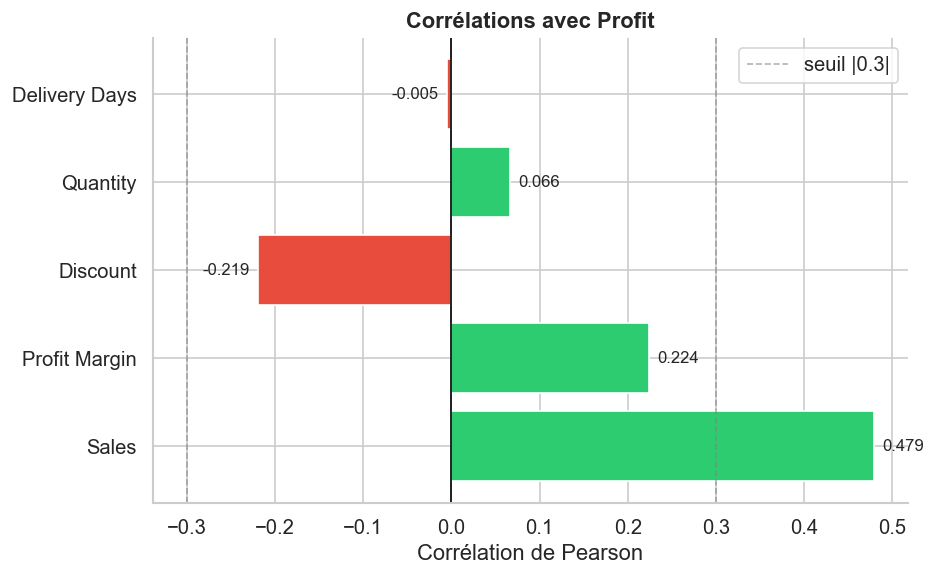

In [25]:
corr_profit = df[['Sales','Profit','Quantity','Discount','Profit Margin','Delivery Days']].corr()['Profit'].drop('Profit').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_profit]
ax.barh(corr_profit.index, corr_profit.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(0.3,  color='gray', linewidth=1, linestyle='--', alpha=0.6, label='seuil |0.3|')
ax.axvline(-0.3, color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlabel('Corrélation de Pearson')
ax.set_title('Corrélations avec Profit', fontweight='bold')
ax.legend()
for i, (k, v) in enumerate(corr_profit.items()):
    ax.text(v + 0.01 if v >= 0 else v - 0.01, i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()

#### Interprétation :
Sales est le seul facteur qui dépasse le seuil significatif de |0.3| avec une corrélation de +0.479, ce qui confirme que c'est le montant de la vente (et non la quantité ou le délai de livraison) qui tire le profit vers le haut, tandis que le Discount reste le seul levier négatif actionnable : le réduire est la décision la plus simple et la plus directe pour améliorer la rentabilité globale.

### 7.2 Simulation ROI — +10% Quantity dans les Top Régions

In [27]:
top_regions = region_stats.head(2).index.tolist()
print(f'Top 2 régions sélectionnées : {top_regions}')

df_top = df[df['Region'].isin(top_regions)].copy()
profit_actuel = df_top['Profit'].sum()

# Ratio moyen Profit/Quantity
profit_per_unit = df_top['Profit'] / df_top['Quantity']
additional_units = df_top['Quantity'] * 0.10
profit_additionnel = (profit_per_unit * additional_units).sum()

profit_simule   = profit_actuel + profit_additionnel
profit_global   = df['Profit'].sum()
profit_global_s = profit_global + profit_additionnel

print(f'\nSimulation : +10% Quantity dans {top_regions}')
print(f'   Profit actuel (top régions) : ${profit_actuel:>12,.0f}')
print(f'   Profit additionnel estimé   : ${profit_additionnel:>12,.0f}')
print(f'   Profit simulé (top régions) : ${profit_simule:>12,.0f}')
print(f'   Impact sur profit global    : +{profit_additionnel/profit_global*100:.1f}%')

Top 2 régions sélectionnées : ['West', 'East']

Simulation : +10% Quantity dans ['West', 'East']
   Profit actuel (top régions) : $     199,941
   Profit additionnel estimé   : $      19,994
   Profit simulé (top régions) : $     219,935
   Impact sur profit global    : +7.0%


#### Interprétation : 
Augmenter de seulement 10% la quantité vendue dans les deux meilleures régions (West et East) rapporterait environ 20 000$ de profit supplémentaire, soit un gain de +7% sur le profit global de toute l'entreprise, ce qui prouve qu'il est bien plus rentable de vendre davantage là où ça marche déjà que d'essayer de redresser les régions faibles.

## 8. Tableau de Synthèse des Facteurs Clés

In [31]:
facteurs = pd.DataFrame({
    'Type Relation': ['Quanti-Quanti', 'Quanti-Quanti', 'Quanti-Quali', 'Quanti-Quali', 'Quanti-Quali', 'Quali-Quali'],
    'Facteur Clé':   ['Discount → Profit Margin', 'Sales → Profit', 'Region → Profit', 'Category → Margin', 'Sub-Category → Profit', 'Category × Region → Margin'],
    'Mesure': [
        f'corr={corr_profit.get("Discount",0):.2f} | Seuil critique : >20% = perte garantie',
        f'corr={df[["Sales","Profit"]].corr().loc["Sales","Profit"]:.2f} | Seul facteur > seuil |0.3|',
        f'West 14.9% vs Central 7.9% | Écart : +7pp | ANOVA p<0.05',
        f'Technology 17.4% ≈ Off.Sup 17.0% >> Furniture 2.5%',
        f'Tables -8.6% | Bookcases -3.0% | Supplies -2.6% (3 SKUs déficitaires)',
        'Furniture×Central : -1.8% (seule combinaison négative) | Off.Sup×West : 23.8% (meilleure)'
    ],
    'Impact Business': [
        'Plafonner les remises à 20% maximum',
        'Simuler +10% Quantity West/East = +7% profit global',
        'Concentrer budget marketing sur West & East',
        'Développer Technology/Off.Sup ; auditer Furniture',
        'Revoir pricing Tables & Bookcases ou retirer du catalogue',
        'Repositionner ou réduire Furniture en Central'
    ]
})
print('=== 🔑 Tableau des Facteurs Clés Identifiés ===')
display(facteurs.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

=== 🔑 Tableau des Facteurs Clés Identifiés ===


,Type Relation,Facteur Clé,Mesure,Impact Business
0,Quanti-Quanti,Discount → Profit Margin,corr=-0.22 | Seuil critique : >20% = perte garantie,Plafonner les remises à 20% maximum
1,Quanti-Quanti,Sales → Profit,corr=0.48 | Seul facteur > seuil |0.3|,Simuler +10% Quantity West/East = +7% profit global
2,Quanti-Quali,Region → Profit,West 14.9% vs Central 7.9% | Écart : +7pp | ANOVA p<0.05,Concentrer budget marketing sur West & East
3,Quanti-Quali,Category → Margin,Technology 17.4% ≈ Off.Sup 17.0% >> Furniture 2.5%,Développer Technology/Off.Sup ; auditer Furniture
4,Quanti-Quali,Sub-Category → Profit,Tables -8.6% | Bookcases -3.0% | Supplies -2.6% (3 SKUs déficitaires),Revoir pricing Tables & Bookcases ou retirer du catalogue
5,Quali-Quali,Category × Region → Margin,Furniture×Central : -1.8% (seule combinaison négative) | Off.Sup×West : 23.8% (meilleure),Repositionner ou réduire Furniture en Central


## 9. Insights Business & Recommandations Stratégiques

In [35]:
print('='*65)
print(' 💡 INSIGHTS BUSINESS - SUPERSTORE ANALYSIS')
print('='*65)

print('\n🌍 RÉGIONS')
for reg in region_stats.sort_values('Profit_total', ascending=False).index:
    row = region_stats.loc[reg]
    flag = ' ✅' if row['Margin_global'] >= 13 else ' ⚠️'
    print(f'  {reg:10s} → Profit: ${row["Profit_total"]:>9,.0f} | Marge: {row["Margin_global"]:>5.1f}%{flag}')

print('\n📦 CATÉGORIES')
for cat in cat_stats.sort_values('Profit_total', ascending=False).index:
    row = cat_stats.loc[cat]
    flag = ' ✅' if row['Margin_global'] >= 10 else ' 🔴'
    print(f'  {cat:20s} → Profit: ${row["Profit_total"]:>9,.0f} | Marge: {row["Margin_global"]:>5.1f}%{flag}')

neg_cats = subcat[subcat['Profit'] < 0].sort_values('Profit')
print(f'\n📚 Sous-catégories déficitaires ({len(neg_cats)}):')
for _, r in neg_cats.iterrows():
    print(f'  {r["Sub-Category"]:20s} ({r["Category"]}) → Profit: ${r["Profit"]:>9,.0f} | Marge: {r["Margin"]:>6.1f}%')

print('\n📊 RECOMMANDATIONS STRATÉGIQUES (par priorité)')
print('  1. Plafonner les discounts à 20% max - au-delà, chaque vente est une perte sèche (-114% marge à >50%)')
print('  2. Simuler +10% Quantity sur West/East - gain estimé +$19,994 soit +7% du profit global')
print('  3. Concentrer le budget marketing sur West (14.9%) et East (13.5%) - écart de +7pp sur Central')
print('  4. Revoir pricing Tables (-8.6%) et Bookcases (-3.0%) - 207k$ de ventes pour -17k$ de profit')
print('  5. Développer Technology & Office Supplies (~17% de marge chacun) au détriment de Furniture (2.5%)')
print('  6. Cibler Home Office (33.8$/commande) et Corporate (30.5$/commande) plutôt que Consumer (25.8$)')
print('  7. Privilégier First Class pour commandes haute valeur (profit moyen : 31.8$ vs 27.5$ Standard)')

print('\n' + '='*65)

 💡 INSIGHTS BUSINESS - SUPERSTORE ANALYSIS

🌍 RÉGIONS
  West       → Profit: $  108,418 | Marge:  14.9% ✅
  East       → Profit: $   91,523 | Marge:  13.5% ✅
  South      → Profit: $   46,749 | Marge:  11.9% ⚠️
  Central    → Profit: $   39,706 | Marge:   7.9% ⚠️

📦 CATÉGORIES
  Technology           → Profit: $  145,455 | Marge:  17.4% ✅
  Office Supplies      → Profit: $  122,491 | Marge:  17.0% ✅
  Furniture            → Profit: $   18,451 | Marge:   2.5% 🔴

📚 Sous-catégories déficitaires (3):
  Tables               (Furniture) → Profit: $  -17,725 | Marge:   -8.6%
  Bookcases            (Furniture) → Profit: $   -3,473 | Marge:   -3.0%
  Supplies             (Office Supplies) → Profit: $   -1,189 | Marge:   -2.5%

📊 RECOMMANDATIONS STRATÉGIQUES (par priorité)
  1. Plafonner les discounts à 20% max - au-delà, chaque vente est une perte sèche (-114% marge à >50%)
  2. Simuler +10% Quantity sur West/East - gain estimé +$19,994 soit +7% du profit global
  3. Concentrer le budget marketi